In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import anndata as ad
from scipy import sparse

/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


20251110_laughney_data
e-bruli

To get the cell barcodes for PeakATail, I converted the cell barcodes back to its original 10X cell barcodes via decoding with the whitelist. Exact way is explained below.
1. I re-downloaded the raw object deposited in the article (https://doi.org/10.1038/s41591-019-0750-6) : https://s3.amazonaws.com/dp-lab-data-public/lung-development-cancer-progression/PATIENT_LUNG_ADENOCARCINOMA_ANNOTATED.h5 
2. Since its h5 object its a bit trickier to read but we manage, I got the DF_ALL (dataframe_all) for all the cells and then convert it to anndata format
3. Saved them as raw: adata.write_h5ad("/home/ebrukocakaya/20251105_laughney_raw.h5ad",
                        adata.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251105_laughney_raw.h5ad")
4. Then I performed the cell barcode conversion with correcting string/categorical type error and run the basic scanpy pipeline with it and save the objects as
        adata.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251110_laughney_all_barcodes_v2_decoded_scanpy_processed.h5ad"), 
                adata.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251110_laughney_macs_barcodes_v2_decoded_scanpy_processed.h5ad")


In [2]:
import h5py
with h5py.File("/mnt/ssd0/20250728_laughney_h5ad_files_ek/nov_laugh/PATIENT_LUNG_ADENOCARCINOMA_ANNOTATED.h5", "r") as f:
    print(list(f.keys()))  # e.g. ['df', 'table', 'mydata']
#here are the keys:
#['DF_ALL', 'DF_EPITHELIAL_NOR', 'DF_EPITHELIAL_NOR_TUMOR', 'DF_EPITHELIAL_NOR_TUMOR_MET', 'DF_LYMPHOID_ALL', 'DF_MYELOID_OTHER_ALL', 'DIMENSIONS_ALL', 
# 'DIMENSIONS_EPITHELIAL_NOR', 'DIMENSIONS_EPITHELIAL_NOR_TUMOR', 'DIMENSIONS_EPITHELIAL_NOR_TUMOR_MET', 'DIMENSIONS_LYMPHOID_ALL', 
# 'DIMENSIONS_MYELOID_OTHER_ALL', 'GENE_RANK_MAST_ALL', 'GENE_RANK_MAST_EPITHELIAL_NOR', 'GENE_RANK_MAST_EPITHELIAL_NOR_TUMOR', 
# 'GENE_RANK_MAST_EPITHELIAL_NOR_TUMOR_MET', 'GENE_RANK_MAST_LYMPHOID_ALL', 'GENE_RANK_MAST_MYELOID_OTHER_ALL', 'INDF_ALL', 'INDF_EPITHELIAL_NOR', 
# 'INDF_EPITHELIAL_NOR_TUMOR', 'INDF_EPITHELIAL_NOR_TUMOR_MET', 'INDF_LYMPHOID_ALL', 'INDF_MYELOID_OTHER_ALL', 'NDF_ALL', 
# 'NDF_EPITHELIAL_NOR', 'NDF_EPITHELIAL_NOR_TUMOR', 'NDF_EPITHELIAL_NOR_TUMOR_MET', 'NDF_LYMPHOID_ALL', 'NDF_MYELOID_OTHER_ALL']

#1 line key: ['DF_ALL', 'DF_EPITHELIAL_NOR', 'DF_EPITHELIAL_NOR_TUMOR', 'DF_EPITHELIAL_NOR_TUMOR_MET', 'DF_LYMPHOID_ALL', 'DF_MYELOID_OTHER_ALL', 'DIMENSIONS_ALL', 'DIMENSIONS_EPITHELIAL_NOR', 'DIMENSIONS_EPITHELIAL_NOR_TUMOR', 'DIMENSIONS_EPITHELIAL_NOR_TUMOR_MET', 'DIMENSIONS_LYMPHOID_ALL', 'DIMENSIONS_MYELOID_OTHER_ALL', 'GENE_RANK_MAST_ALL', 'GENE_RANK_MAST_EPITHELIAL_NOR', 'GENE_RANK_MAST_EPITHELIAL_NOR_TUMOR', 'GENE_RANK_MAST_EPITHELIAL_NOR_TUMOR_MET', 'GENE_RANK_MAST_LYMPHOID_ALL', 'GENE_RANK_MAST_MYELOID_OTHER_ALL', 'INDF_ALL', 'INDF_EPITHELIAL_NOR', 'INDF_EPITHELIAL_NOR_TUMOR', 'INDF_EPITHELIAL_NOR_TUMOR_MET', 'INDF_LYMPHOID_ALL', 'INDF_MYELOID_OTHER_ALL', 'NDF_ALL', 'NDF_EPITHELIAL_NOR', 'NDF_EPITHELIAL_NOR_TUMOR', 'NDF_EPITHELIAL_NOR_TUMOR_MET', 'NDF_LYMPHOID_ALL', 'NDF_MYELOID_OTHER_ALL']


['DF_ALL', 'DF_EPITHELIAL_NOR', 'DF_EPITHELIAL_NOR_TUMOR', 'DF_EPITHELIAL_NOR_TUMOR_MET', 'DF_LYMPHOID_ALL', 'DF_MYELOID_OTHER_ALL', 'DIMENSIONS_ALL', 'DIMENSIONS_EPITHELIAL_NOR', 'DIMENSIONS_EPITHELIAL_NOR_TUMOR', 'DIMENSIONS_EPITHELIAL_NOR_TUMOR_MET', 'DIMENSIONS_LYMPHOID_ALL', 'DIMENSIONS_MYELOID_OTHER_ALL', 'GENE_RANK_MAST_ALL', 'GENE_RANK_MAST_EPITHELIAL_NOR', 'GENE_RANK_MAST_EPITHELIAL_NOR_TUMOR', 'GENE_RANK_MAST_EPITHELIAL_NOR_TUMOR_MET', 'GENE_RANK_MAST_LYMPHOID_ALL', 'GENE_RANK_MAST_MYELOID_OTHER_ALL', 'INDF_ALL', 'INDF_EPITHELIAL_NOR', 'INDF_EPITHELIAL_NOR_TUMOR', 'INDF_EPITHELIAL_NOR_TUMOR_MET', 'INDF_LYMPHOID_ALL', 'INDF_MYELOID_OTHER_ALL', 'NDF_ALL', 'NDF_EPITHELIAL_NOR', 'NDF_EPITHELIAL_NOR_TUMOR', 'NDF_EPITHELIAL_NOR_TUMOR_MET', 'NDF_LYMPHOID_ALL', 'NDF_MYELOID_OTHER_ALL']


In [2]:
#read the h5 file and check the keys 
import h5py
with h5py.File("PATIENT_LUNG_ADENOCARCINOMA_ANNOTATED.h5", "r") as f:
    f.visititems(lambda name, obj: print(name, type(obj)))


DF_ALL <class 'h5py._hl.group.Group'>
DF_ALL/axis0 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label0 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label1 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label2 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label3 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label4 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label5 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_label6 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level0 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level1 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level2 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level3 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level4 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level5 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/axis1_level6 <class 'h5py._hl.dataset.Dataset'>
DF_ALL/block0_items <class 'h5py._hl.dataset.Dataset'>
DF_ALL/block0_values <class 'h5py._hl.dataset.Dataset'>
DF_EPITHELIAL_NOR <class 'h5py._h

In [3]:
adata = pd.read_hdf("PATIENT_LUNG_ADENOCARCINOMA_ANNOTATED.h5", "DF_ALL")
adata

A1BG  \
Sample ID Legend              Cell ID CELL_TYPE  Meta-Source META_CELL_TYPE PHENOGRAPH_CLASS         
0         RU653_TUMOR_1AS_UTR 0       Tm         TUMOR       Lymphoid       0_LYMPHOID         0.0   
                              2       MACROPHAGE TUMOR       Myeloid        30_MYELOID_OTHER   0.0   
                              3       DENDRITIC  TUMOR       Myeloid        1_MYELOID_OTHER    0.0   
                              4       Tm         TUMOR       Lymphoid       0_LYMPHOID         2.0   
                              6       Tm         TUMOR       Lymphoid       8_LYMPHOID         0.0   
...                                                                                            ...   
17        RU701_BRAINMET_4    63006   Tm         MET         Lymphoid       0_LYMPHOID         0.0   
                              63008   Tm         MET         Lymphoid       0_LYMPHOID         0.0   
                              63010   Tm         MET         Lymphoid       2_LYMPHOID         1.0   
                              63011   Tm         MET         Lymphoid       2_LYMPHOID         0.0   
                              63012   MACROPHAGE MET         Myeloid        13_MYELOID_OTHER   0.0   

                                                                                              A1CF  \
Sample ID Legend              Cell ID CELL_TYPE  Meta-Source META_CELL_TYPE PHENOGRAPH_CLASS         
0         RU653_TUMOR_1AS_UTR 0       Tm         TUMOR       Lymphoid       0_LYMPHOID         0.0   
                              2       MACROPHAGE TUMOR       Myeloid        30_MYELOID_OTHER   0.0   
                              3       DENDRITIC  TUMOR       Myeloid        1_MYELOID_OTHER    0.0   
                              4       Tm         TUMOR       Lymphoid       0_LYMPHOID         0.0   
                              6       Tm         TUMOR       Lymphoid       8_LYMPHOID         0.0   
...                                                                                            ...   
17        RU701_BRAINMET_4    63006   Tm         MET         Lymphoid       0_LYMPHOID         0.0   
                              63008   Tm         MET         Lymphoid       0_LYMPHOID         0.0   
                              63010   Tm         MET         Lymphoid       2_LYMPHOID         0.0   
                              63011   Tm         MET         Lymphoid       2_LYMPHOID         0.0   
                              63012   MACROPHAGE MET         Myeloid        13_MYELOID_OTHER   0.0   

                                                                                              A2M  \
Sample ID Legend              Cell ID CELL_TYPE  Meta-Source META_CELL_TYPE PHENOGRAPH_CLASS        
0         RU653_TUMOR_1AS_UTR 0       Tm         TUMOR       Lymphoid       0_LYMPHOID        0.0   
                              2       MACROPHAGE TUMOR       Myeloid        30_MYELOID_OTHER  9.0   
                              3       DENDRITIC  TUMOR       Myeloid        1_MYELOID_OTHER   0.0   
                              4       Tm         TUMOR       Lymphoid       0_LYMPHOID        0.0   
                              6       Tm         TUMOR       Lymphoid       8_LYMPHOID        0.0   
...                                                                                           ...   
17        RU701_BRAINMET_4    63006   Tm         MET         Lymphoid       0_LYMPHOID        0.0   
                              63008   Tm         MET         Lymphoid       0_LYMPHOID        0.0   
                              63010   Tm         MET         Lymphoid       2_LYMPHOID        0.0   
                              63011   Tm         MET         Lymphoid       2_LYMPHOID        0.0   
                              63012   MACROPHAGE MET         Myeloid        13_MYELOID_OTHER  0.0   

                                                                                              A2ML1  \
Sample ID Legend       

In [ ]:


path = "PATIENT_LUNG_ADENOCARCINOMA_ANNOTATED.h5"

# 1) Load RAW table (DF_ALL)
df = pd.read_hdf(path, key="DF_ALL")

# 2) If the ROW index is a MultiIndex, push its levels into real columns
if isinstance(df.index, pd.MultiIndex):
    lvl_names = [n if n is not None else f"index_level_{i}" for i, n in enumerate(df.index.names)]
    df.index.set_names(lvl_names, inplace=True)
    df = df.reset_index()

# 3) Identify metadata (obs) columns vs expression (genes)
known_meta = {
    "sample id", "legend", "cell id", "cell_type",
    "meta-source", "meta_cell_type", "phenograph_class"
}
is_meta = []
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        is_meta.append(True)
    else:
        is_meta.append(c.lower() in known_meta)
is_meta = pd.Index(df.columns)[is_meta]
expr_cols = df.columns.difference(is_meta)

obs  = df[is_meta].copy()
expr = df[expr_cols].copy()       # raw counts

# 4) Make cell IDs (obs_names)
def find_col(candidates):
    lc = {c.lower(): c for c in obs.columns}
    for name in candidates:
        if name in lc:
            return lc[name]
    return None

sample_col = find_col(["sample id", "sample_id", "sample"])
cellid_col = find_col(["cell id", "cell_id", "cellid", "cell"])

if sample_col and cellid_col:
    obs_names = obs[sample_col].astype(str) + "_" + obs[cellid_col].astype(str)
else:
    obs_names = obs.index.astype(str)

# 5) Build AnnData with RAW counts in .X (sparse for memory)
adata = ad.AnnData(
    X   = sparse.csr_matrix(expr.to_numpy()),             # RAW in .X
    obs = obs,
    var = pd.DataFrame(index=expr.columns.astype(str))
)
adata.obs_names = pd.Index(obs_names, dtype=str)
adata.obs_names_make_unique()
adata.var_names = adata.var.index.astype(str)
adata.var_names_make_unique()

# Optional: keep an explicit copy of raw counts as a layer
# (not necessary since .X already holds raw, but can be handy)
# adata.layers["raw_counts"] = adata.X.copy()

# 6) (Optional) attach precomputed embedding
try:
    emb = pd.read_hdf(path, key="DIMENSIONS_ALL")
    if isinstance(emb.index, pd.MultiIndex):
        emb.index = emb.index.to_flat_index().map(lambda x: "|".join(map(str, x)))
    emb = emb.reindex(adata.obs_names)
    if emb.shape[1] == 2:
        adata.obsm["X_umap"] = emb.to_numpy()
    elif emb.shape[1] >= 3:
        adata.obsm["X_pca"] = emb.to_numpy()
except Exception:
    pass

print(adata)
# Save if you want:
# adata.write_h5ad("/home/ebrukocakaya/20251105_laughney_raw.h5ad", compression="gzip")


/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 40505 × 19222
    obs: 'Sample ID', 'Legend', 'Cell ID', 'CELL_TYPE', 'Meta-Source', 'META_CELL_TYPE', 'PHENOGRAPH_CLASS'
    obsm: 'X_pca'


In [8]:
adata.write_h5ad("/home/ebrukocakaya/20251105_laughney_raw.h5ad")
adata.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251105_laughney_raw.h5ad")

In [ ]:
#adata.obs["CELL_TYPE"].value_counts()
macrophages= adata[adata.obs.CELL_TYPE=="MACROPHAGE"]
macrophages
macrophages.write_h5ad("/home/ebrukocakaya/20251105_laughney_macrophages_raw.h5ad")
macrophages.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251105_laughney_macrophages_raw.h5ad")

View of AnnData object with n_obs × n_vars = 3503 × 19222
    obs: 'Sample ID', 'Legend', 'Cell ID', 'CELL_TYPE', 'Meta-Source', 'META_CELL_TYPE', 'PHENOGRAPH_CLASS'
    obsm: 'X_pca'

Each barcode ID has two parts:
0 / 1 / 17 → the library or sequencing batch index
(if you processed multiple input FASTQs or libraries)
2, 80, 63012 → the barcode index inside that library
These integer indices point to SEQC’s whitelist file — the file you gave with
--barcode-files during processing (often something like whitelist/3M-february-2018.txt).
That file lists all possible 10x barcodes line-by-line, so 0_2 means:
“library 0, barcode #2 from that whitelist”

In [ ]:
from pandas.api.types import is_string_dtype

# ------------------ INPUTS ------------------
h5ad_in  = "/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251105_laughney_macrophages_raw.h5ad"
h5ad_out = "/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251106_laughney_all_barcodes_v2_decoded.h5ad"
whitelist_path = "/mnt/ssd0/20250728_laughney_h5ad_files_ek/nov_laugh/737K-august-2016.txt"
# --------------------------------------------

#  Load data & whitelist
adata = sc.read_h5ad(h5ad_in)
wl = [line.strip() for line in open(whitelist_path) if line.strip()]
W = len(wl)  # 737,280 for 10x v2 whitelist

print(f"Loaded {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Whitelist loaded: {W:,} barcodes")

# Split SEQC-style names "lib_idx"
libs, idxs = [], []
for x in adata.obs_names.astype(str):
    parts = x.split("_")
    if len(parts) != 2:
        raise ValueError(f"Unexpected obs name format: {x}")
    a, b = parts
    libs.append(int(a))
    idxs.append(int(b))

# Infer zero- vs one-based indices
m, M = min(idxs), max(idxs)
one_based = (m >= 1 and M <= W) or (M == W)
print(f"Detected {'one-based' if one_based else 'zero-based'} indexing.")

# Map indices → ACGT barcodes
decoded = [wl[i-1 if one_based else i] for i in idxs]

# Assign decoded barcodes + add library info
adata.obs["library"] = libs
adata.obs["old_obs_names"] = adata.obs_names.astype(str)
adata.obs_names = pd.Index(decoded, dtype=str)
adata.obs_names_make_unique()

# Sanity checks
assert all(len(bc.replace("-1","")) == 16 for bc in adata.obs_names), "Unexpected barcode length (expected 16bp)"
if not adata.obs_names.is_unique:
    print("Warning: duplicate barcodes detected — suffixing for uniqueness.")
    adata.obs_names = adata.obs_names.astype(str) + pd.Index(range(adata.n_obs)).astype(str)

print("Decoded barcodes successfully. Example:", adata.obs_names[:5].tolist())

# Fix string/categorical dtype issues before writing
if adata.is_view:
    adata = adata.copy()

# Ensure index type consistency
adata.obs_names = adata.obs_names.astype(str)
adata.var_names = adata.var_names.astype(str)

# Convert string columns to categories or objects
for df in (adata.obs, adata.var):
    for c in df.columns:
        if is_string_dtype(df[c]) or str(df[c].dtype).startswith("string"):
            print(f"Converting column '{c}' from {df[c].dtype} to category")
            df[c] = df[c].astype("category")

# Extra safety for .uns elements
for k, v in list(adata.uns.items()):
    if isinstance(v, pd.Series) and is_string_dtype(v):
        adata.uns[k] = v.astype(object)
    elif isinstance(v, (list, tuple)) and len(v) > 0 and isinstance(v[0], str):
        adata.uns[k] = list(map(str, v))

#Write the clean decoded AnnData object
#adata.write_h5ad(h5ad_out)
#print(f"\n Saved decoded AnnData to:\n{h5ad_out}")

# Optional quick test
#print("\nReload test:")
#test = sc.read_h5ad(h5ad_out)
#print(f"Reloaded OK — shape {test.shape}")
#print("First 5 barcodes:", list(test.obs_names[:5]))


Loaded 3503 cells × 19222 genes
Whitelist loaded: 737,280 barcodes
Detected one-based indexing.
Decoded barcodes successfully. Example: ['AAACCTGAGAAACCGC', 'AAACCTGAGAGTTGGC', 'AAACCTGAGCCCAATT', 'AAACCTGAGCGCCTTG', 'AAACCTGAGCGTGAGT']
Converting column 'Sample ID' from category to category
Converting column 'Legend' from category to category
Converting column 'Cell ID' from object to category
Converting column 'CELL_TYPE' from category to category
Converting column 'Meta-Source' from category to category
Converting column 'META_CELL_TYPE' from category to category
Converting column 'PHENOGRAPH_CLASS' from category to category
Converting column 'old_obs_names' from object to category

 Saved decoded AnnData to:
/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251106_laughney_all_barcodes_v2_decoded.h5ad


this is for the whole Laughney dataset:

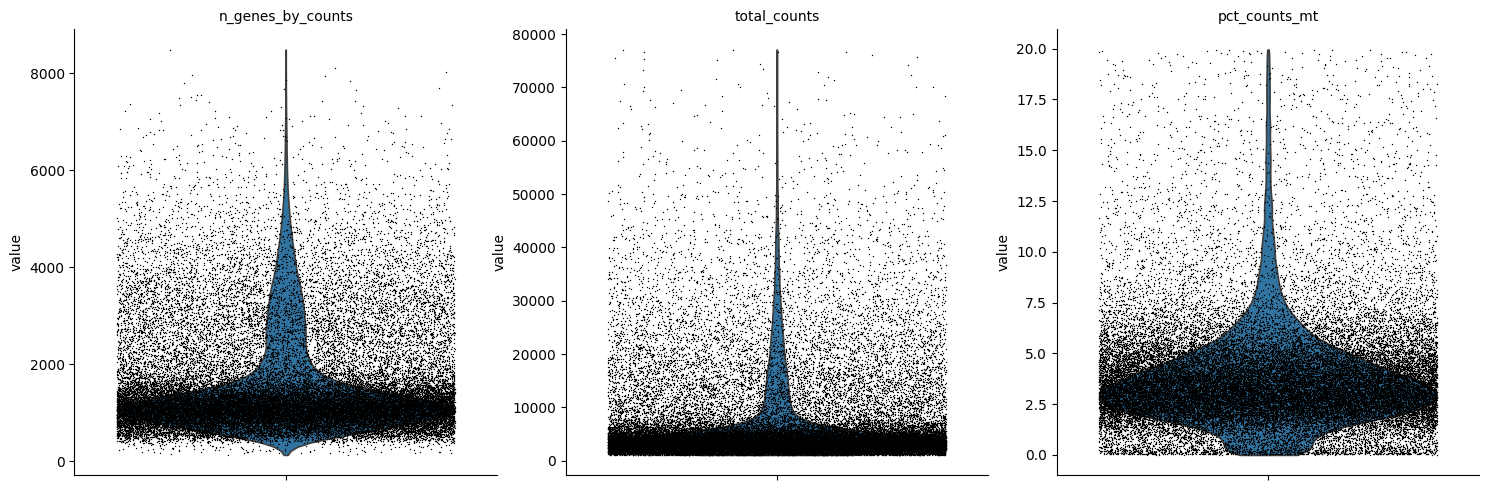

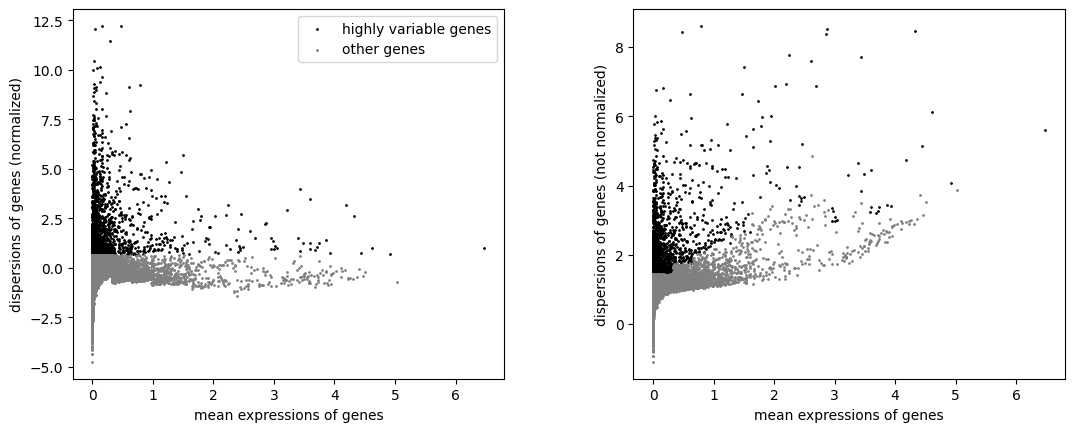

/tmp/ipykernel_1989677/3924354085.py:22: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, n_iterations=2)


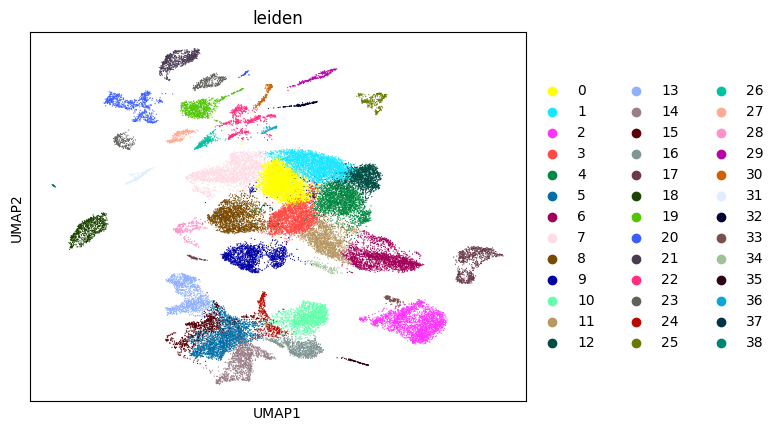

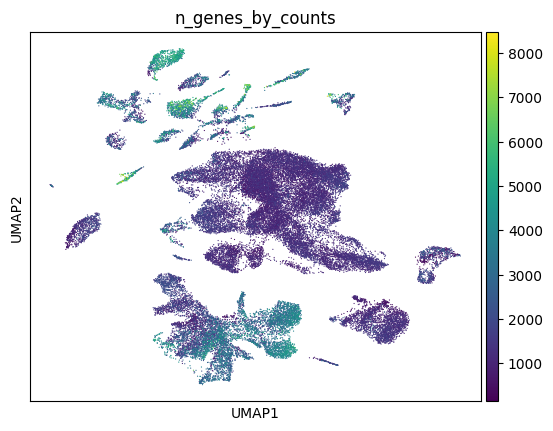

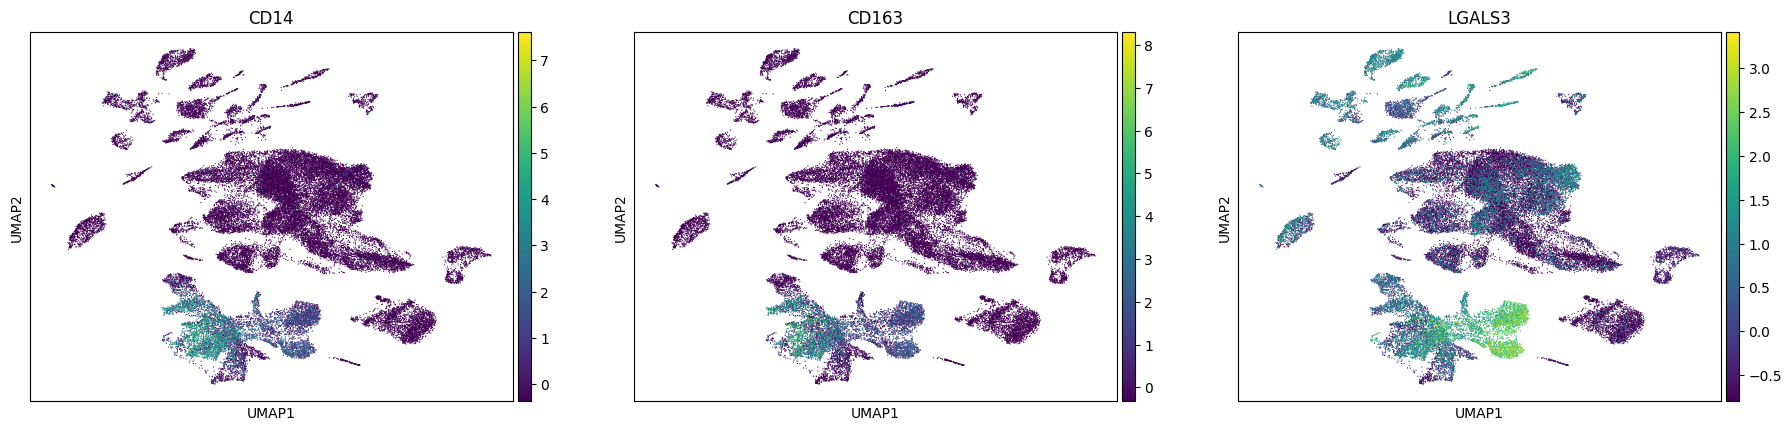

In [ ]:

adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-')  # human genes start with 'MT-'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
# --- Basic preprocessing to ensure it's valid ---
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()


# --- Very fast normalization + PCA + UMAP ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)


sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, n_iterations=2)
sc.pl.umap(adata, color=["leiden"])
sc.pl.umap(adata, color=['n_genes_by_counts'])
sc.pl.umap(adata, color=['CD14','CD163','LGALS3'])

In [31]:
#sc.pl.umap(adata, color=['MARCO','ITGAM','LGALS3'])

adata.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251110_laughney_all_barcodes_v2_decoded_scanpy_processed.h5ad")
#sc.pl.umap(adata, color= )

this is for the macrophage subset of Laughney:
I know the code is both for adata object

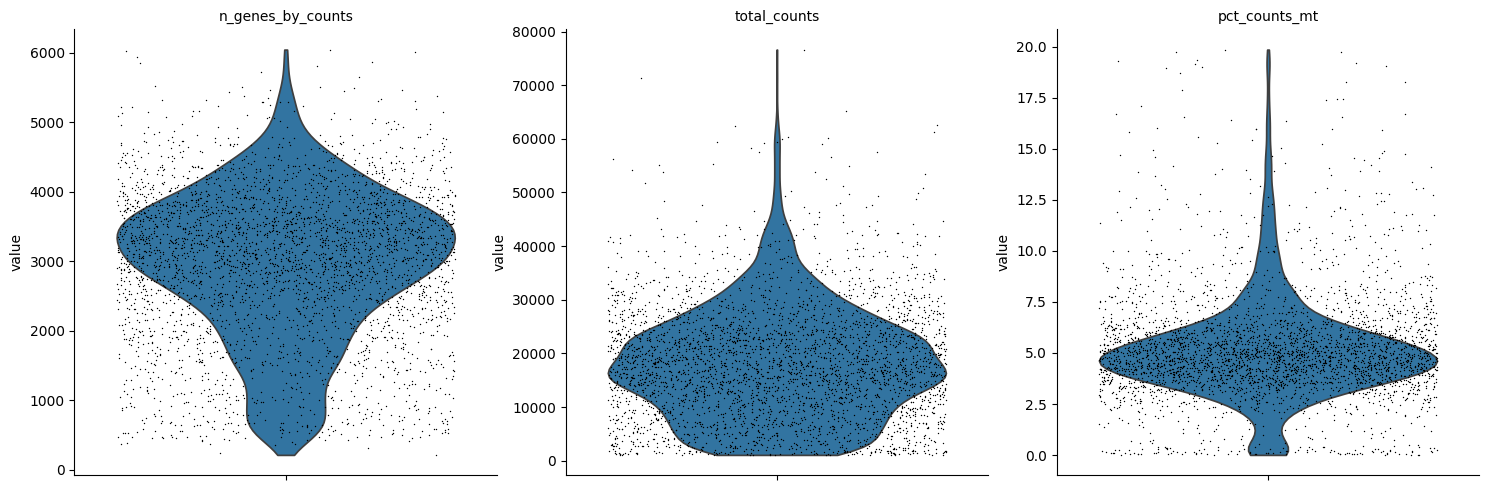

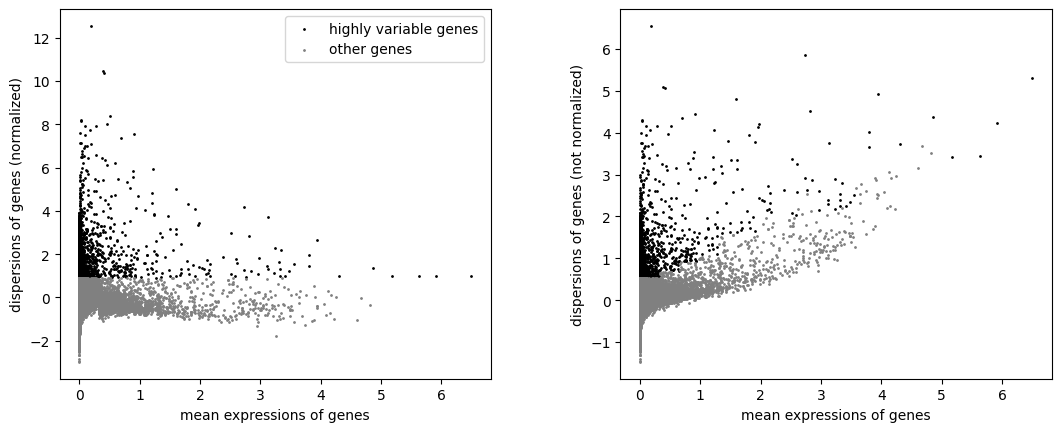

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x77965c8eb790>
Traceback (most recent call last):
  File "/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/ebrukocakaya/anaconda3/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


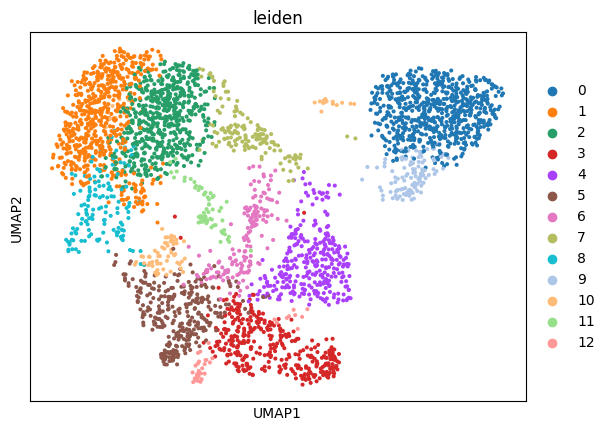

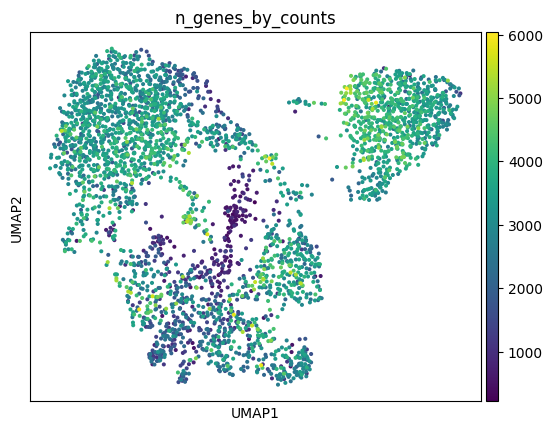

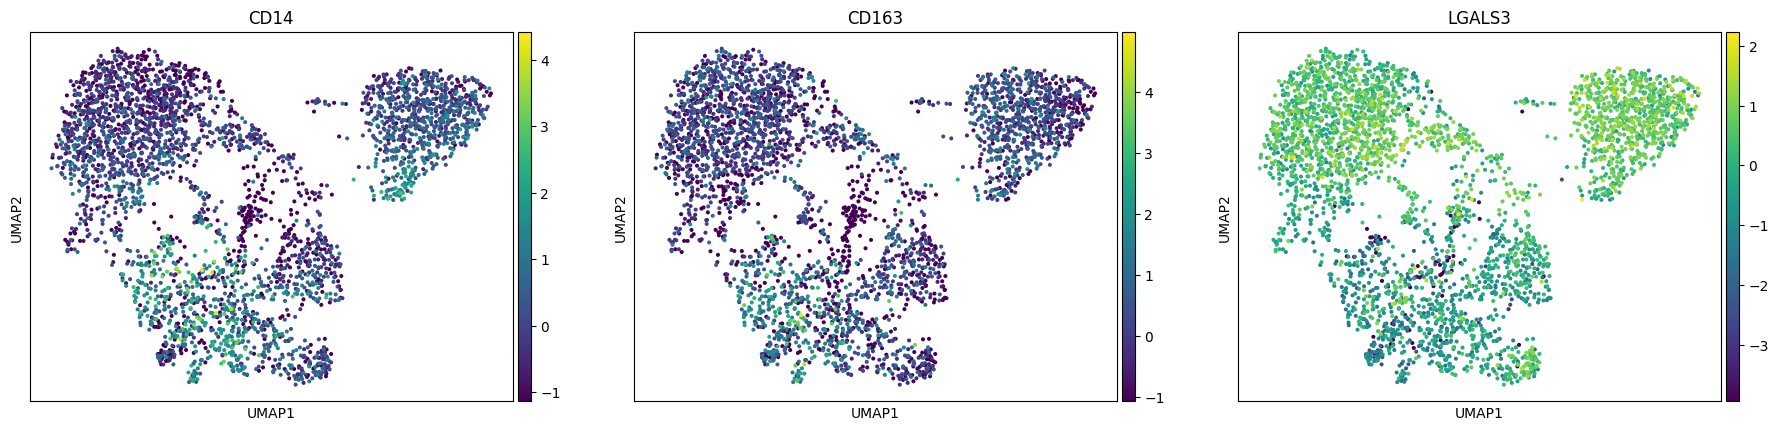

In [33]:
adata.var['mt'] = adata.var_names.str.upper().str.startswith('MT-')  # human genes start with 'MT-'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
# --- Basic preprocessing to ensure it's valid ---
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()


# --- Very fast normalization + PCA + UMAP ---
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)


sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, n_iterations=2)
sc.pl.umap(adata, color=["leiden"])
sc.pl.umap(adata, color=['n_genes_by_counts'])
sc.pl.umap(adata, color=['CD14','CD163','LGALS3'])

In [38]:
adata.write_h5ad("/mnt/ssd0/20250728_laughney_h5ad_files_ek/20251110_laughney_macs_barcodes_v2_decoded_scanpy_processed.h5ad")